# FiCO₂ ⇌ PaCO₂ — a practical tutorial

**What this is.** A short, task-oriented guide to converting between the two ways a CO₂ challenge
gets reported: the **inspired fraction** (FiCO₂, e.g. “5% CO₂”) and the **arterial / end-tidal
partial pressure** (PaCO₂ ≈ P<sub>ET</sub>CO₂, in mmHg or kPa).

**Why it isn’t just a unit conversion.** Inspired CO₂ raises arterial CO₂, but the rise itself
stimulates ventilation, which blows off part of the extra CO₂. The two measures are therefore
related through the *hypercapnic ventilatory response* (HCVR), not by a fixed ratio.

> **This notebook does not re-derive the model.** The full derivation, the physiological
> assumptions, the provenance of every constant, and the validation live in the accompanying
> **technical note**. Here we just *use* the converter. Read the note first if you want to know
> *why*; read this if you want to know *how*.

---
### Contents
1. [Setup](#setup)
2. [The one equation](#eq)
3. [Forward: PaCO₂ → FiCO₂](#fwd)
4. [Reverse: FiCO₂ → PaCO₂](#rev)
5. [Reference table](#table)
6. [How much does the slope matter?](#slope)
7. [Short challenges: the time-dependent model](#time)
8. [When *not* to use this](#limits)
9. [Interactive prompt](#cli)
10. [Where the numbers come from](#prov)


<a id='setup'></a>
## 1. Setup

Everything lives in a single dependency-free module, `fico2_paco2_converter.py`.
(`numpy` / `matplotlib` are only needed for the figures.)


In [1]:
from fico2_paco2_converter import (
    params_from_baseline,      # you know the subject's resting PaCO2
    params_resting_default,    # you don't -> literature resting values
    paco2_to_fico2,            # forward:  PaCO2 -> FiCO2
    fico2_to_paco2,            # reverse:  FiCO2 -> PaCO2
    ParamsTimeDependent,       # time-dependent model (duration matters)
    fico2_to_paco2_timedep,
    mmhg_to_kpa, kpa_to_mmhg,
)

print('ready')


ready


<a id='eq'></a>
## 2. The one equation

Alveolar CO₂ is what you inspire, plus what your metabolism adds, divided by how hard you breathe:

$$P_aCO_2 \;=\; \underbrace{F_iCO_2\,(P_{atm}-P_{H_2O})}_{\text{what you breathe in}}
\;+\; \underbrace{\frac{K\,\dot V_{CO_2}}{\dot V_A(P_aCO_2)}}_{\text{what you make, divided by how hard you breathe}}$$

and ventilation itself responds to CO₂, linearly over the working range:

$$\dot V_A(P_aCO_2) \;=\; \dot V_{A,\text{base}} \;+\; S\,(P_aCO_2 - P_aCO_{2,\text{base}})$$

Because $\dot V_A$ is linear in $P_aCO_2$, the whole thing is a **quadratic** in $P_aCO_2$ — so both
directions have exact closed-form solutions. No iteration needed.

| symbol | default | meaning |
|---|---|---|
| $S$ | 2.69 L·min⁻¹·mmHg⁻¹ | HCVR slope (Hirshman et al. 1975, n = 44; individuals span 1.00–5.95) |
| $\dot V_{CO_2}$ | 200 mL·min⁻¹ | CO₂ output (STPD) |
| $P_aCO_{2,\text{base}}$ | 40 mmHg | resting arterial CO₂ |
| $K$ | 0.863 | STPD→BTPS unit constant |
| $P_{atm}-P_{H_2O}$ | 713 mmHg | dry-gas pressure at sea level |


<a id='fwd'></a>
## 3. Forward — “I want a PaCO₂ of X. What FiCO₂ do I give?”

This is the common design question when planning a gas challenge.


In [2]:
paco2_target = 50.0   # mmHg — the hypercapnic level you want
paco2_base   = 40.0   # mmHg — the subject's resting PaCO2

p = params_from_baseline(paco2_base)
fico2 = paco2_to_fico2(paco2_target, p)

print(f'To reach PaCO2 = {paco2_target:.1f} mmHg from a baseline of {paco2_base:.0f} mmHg,')
print(f'  give FiCO2 = {fico2:.2f} %')
print(f'  (ventilation at target: {p.VA(paco2_target):.1f} L/min, up from {p.VA_base:.1f} at rest)')


To reach PaCO2 = 50.0 mmHg from a baseline of 40 mmHg,
  give FiCO2 = 6.24 %
  (ventilation at target: 31.2 L/min, up from 4.3 at rest)


<a id='rev'></a>
## 4. Reverse — “The paper says 5% CO₂. What PaCO₂ was that?”

This is the common question when *reading* the literature, and the reason the converter exists:
it puts challenges reported as `%` and challenges reported as `mmHg` onto one scale.


In [3]:
for fi in (3, 5, 7):
    pa = fico2_to_paco2(fi, p)
    print(f'FiCO2 {fi:>2}%  ->  PaCO2 = {pa:5.1f} mmHg = {mmhg_to_kpa(pa):.2f} kPa'
          f'   ({pa - p.PaCO2_base:+.1f} mmHg from baseline)')


FiCO2  3%  ->  PaCO2 =  41.6 mmHg = 5.54 kPa   (+1.6 mmHg from baseline)
FiCO2  5%  ->  PaCO2 =  45.1 mmHg = 6.02 kPa   (+5.1 mmHg from baseline)
FiCO2  7%  ->  PaCO2 =  54.0 mmHg = 7.20 kPa   (+14.0 mmHg from baseline)


### If you don’t know the subject’s baseline

Most papers don’t report it. Use the literature resting fallback
(PaCO₂ = 40 mmHg, $\dot V_A$ = 4.2 L·min⁻¹). The two are not perfectly self-consistent, but the
ventilatory feedback absorbs the difference — FiCO₂ = 0 still returns ≈40.0 mmHg.


In [4]:
p_default = params_resting_default()
print(f'baseline unknown -> VA_base = {p_default.VA_base:.1f} L/min')
print(f'  sanity check: FiCO2 0% -> PaCO2 = {fico2_to_paco2(0.0, p_default):.2f} mmHg  (should be ~40)')
print(f'  FiCO2 5%      -> PaCO2 = {fico2_to_paco2(5.0, p_default):.2f} mmHg')


baseline unknown -> VA_base = 4.2 L/min
  sanity check: FiCO2 0% -> PaCO2 = 40.04 mmHg  (should be ~40)
  FiCO2 5%      -> PaCO2 = 45.17 mmHg


<a id='table'></a>
## 5. Reference table

Steady-state conversion at sea level, baseline 40 mmHg, S = 2.69. Handy for reading papers.


In [5]:
print(f"{'FiCO2 %':>8} {'PICO2 mmHg':>11} {'PaCO2 mmHg':>11} {'PaCO2 kPa':>10}")
print('-' * 44)
for fi in (0, 2, 3, 4, 5, 6, 7, 8):
    pa = fico2_to_paco2(fi, p)
    print(f'{fi:8.0f} {fi/100*p.Pdry:11.1f} {pa:11.1f} {mmhg_to_kpa(pa):10.2f}')


 FiCO2 %  PICO2 mmHg  PaCO2 mmHg  PaCO2 kPa
--------------------------------------------
       0         0.0        40.0       5.33
       2        14.3        40.8       5.44
       3        21.4        41.6       5.54
       4        28.5        42.9       5.72
       5        35.6        45.1       6.02
       6        42.8        48.9       6.52
       7        49.9        54.0       7.20
       8        57.0        60.0       8.00


<a id='slope'></a>
## 6. How much does the slope matter?

**A lot — it is the single biggest source of uncertainty.** $S$ is a *population mean*. Hirshman
et al. (1975) measured 44 healthy adults: mean 2.69, but individuals ranged from **1.00 to 5.95**.

So treat the output as a population-level estimate, not a prediction for one person.


In [6]:
print(f"{'S':>6} {'PaCO2 (5% CO2)':>16}")
print('-' * 24)
for S in (1.00, 2.69, 5.95):
    ps = params_from_baseline(40.0, S=S)
    print(f'{S:6.2f} {fico2_to_paco2(5.0, ps):16.1f}')
print('\n-> a 5% challenge could mean anything from ~43 to ~49 mmHg, depending on the subject.')


     S   PaCO2 (5% CO2)
------------------------
  1.00             48.8
  2.69             45.1
  5.95             43.1

-> a 5% challenge could mean anything from ~43 to ~49 mmHg, depending on the subject.


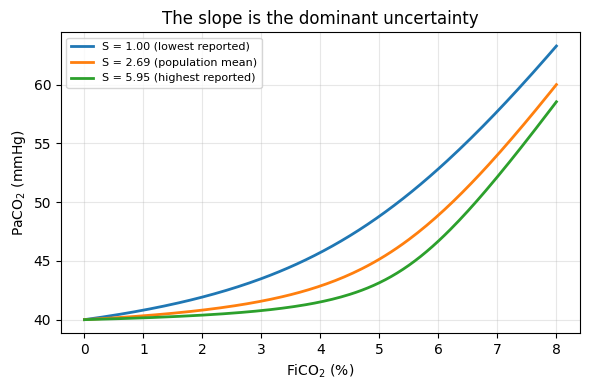

In [7]:
import numpy as np, matplotlib.pyplot as plt

grid = np.linspace(0, 8, 161)
plt.figure(figsize=(6, 4))
for S, lab in [(1.00, 'S = 1.00 (lowest reported)'),
               (2.69, 'S = 2.69 (population mean)'),
               (5.95, 'S = 5.95 (highest reported)')]:
    ps = params_from_baseline(40.0, S=S)
    plt.plot(grid, [fico2_to_paco2(f, ps) for f in grid], lw=2, label=lab)
plt.xlabel('FiCO$_2$ (%)'); plt.ylabel('PaCO$_2$ (mmHg)')
plt.title('The slope is the dominant uncertainty')
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


<a id='time'></a>
## 7. Short challenges: the time-dependent model

Everything above assumes the ventilatory response has **fully developed**. It hasn’t, in the first
few minutes. Ventilation ramps up with a fast (carotid-body) and a slow (central) component, so
early in a challenge less CO₂ is being blown off and **the true PaCO₂ is transiently higher**.

The time-dependent model adds exactly one variable — the duration $t$ — by scaling the slope:

$$\phi(t) = f\,(1-e^{-t/\tau_1}) + (1-f)\,(1-e^{-t/\tau_2}), \qquad S_{\text{eff}}(t) = \phi(t)\cdot S$$

with $\tau_1$ = 12.3 s, $\tau_2$ = 156 s, $f$ = 0.32 (subject-weighted means of Swanson & Bellville
1975, Bellville et al. 1979 and Dahan et al. 1990 — see §10).

**It is the same model with a smaller slope.** Nothing else changes.


In [8]:
pt = ParamsTimeDependent()

print('Effective slope as the response develops (steady-state S = 2.69):')
for t in (10, 30, 60, 120, 300, 600, None):
    lab = 'steady' if t is None else f'{t:>4} s'
    print(f'  t = {lab}:  phi = {pt.phi(t):.3f}  ->  S_eff = {pt.S_eff(t):.2f}')

print('\nPaCO2 during a fixed 7% challenge (transiently higher early):')
for t in (10, 60, 300, 600, None):
    lab = 'steady' if t is None else f'{t:>4} s'
    print(f'  t = {lab}:  PaCO2 = {fico2_to_paco2_timedep(7, pt, t_s=t):.1f} mmHg')


Effective slope as the response develops (steady-state S = 2.69):
  t =   10 s:  phi = 0.220  ->  S_eff = 0.59
  t =   30 s:  phi = 0.411  ->  S_eff = 1.11
  t =   60 s:  phi = 0.534  ->  S_eff = 1.44
  t =  120 s:  phi = 0.685  ->  S_eff = 1.84
  t =  300 s:  phi = 0.900  ->  S_eff = 2.42
  t =  600 s:  phi = 0.985  ->  S_eff = 2.65
  t = steady:  phi = 1.000  ->  S_eff = 2.69

PaCO2 during a fixed 7% challenge (transiently higher early):
  t =   10 s:  PaCO2 = 60.4 mmHg
  t =   60 s:  PaCO2 = 56.2 mmHg
  t =  300 s:  PaCO2 = 54.3 mmHg
  t =  600 s:  PaCO2 = 54.1 mmHg
  t = steady:  PaCO2 = 54.0 mmHg


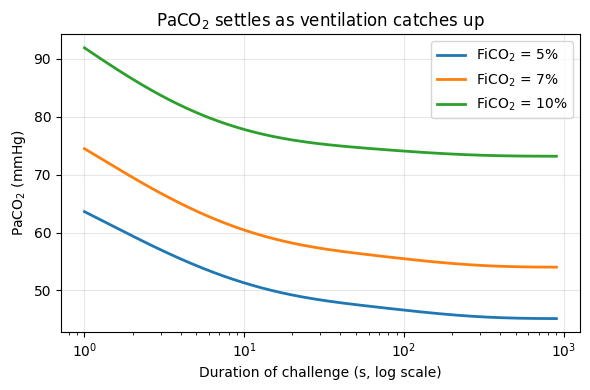

In [9]:
ts = np.logspace(0, np.log10(900), 200)
plt.figure(figsize=(6, 4))
for fi in (5, 7, 10):
    plt.plot(ts, [fico2_to_paco2_timedep(fi, pt, t_s=t) for t in ts], lw=2, label=f'FiCO$_2$ = {fi}%')
plt.xscale('log')
plt.xlabel('Duration of challenge (s, log scale)'); plt.ylabel('PaCO$_2$ (mmHg)')
plt.title('PaCO$_2$ settles as ventilation catches up')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()


**Rule of thumb.** By ~5 min the difference is small; by ~10 min it has vanished
($S_{\text{eff}} = S$). So for a challenge held for tens of minutes — which is most BOLD-MRI and
CVR protocols — the **steady-state model is enough**. Reach for the time-dependent model only for
short or transient challenges.


<a id='limits'></a>
## 8. When *not* to use this

Being honest about the bounds is more useful than the converter itself:

- **Above PaCO₂ ≈ 80 mmHg.** The HCVR saturates and no slope is measured there. Use a *measured*
  PaCO₂ instead. (Beyond ~30% inspired CO₂ ventilation is actively depressed — narcosis.)
- **Anaesthetised subjects.** Anaesthesia blunts the slope (roughly halved or worse at ~1 MAC).
  Substitute an agent- and dose-appropriate $S$; don’t use 2.69.
- **Animals.** Mass-specific metabolic rate is far higher in small mammals. The *form* of the
  equation holds, but every constant must be re-parameterised — you cannot rescale human values.
- **Diseased lungs.** The model assumes PaCO₂ ≈ P<sub>A</sub>CO₂ ≈ P<sub>ET</sub>CO₂. Appreciable
  V/Q mismatch or shunt breaks that.
- **Any individual subject.** $S$ spans 1.00–5.95 between people. This is a population tool for
  *harmonising reported challenges across studies*, not a bedside predictor.


<a id='cli'></a>
## 9. Interactive prompt

The same thing as a guided prompt (also available as `python fico2_paco2_converter.py -i`).
It asks for the model (steady-state or time-dependent), then the direction.


In [ ]:
from fico2_paco2_converter import interactive
interactive()


<a id='prov'></a>
## 10. Where the numbers come from

Every constant traces to a **human** study. No value is assumed or invented.

| parameter | value | source |
|---|---|---|
| $S$ | 2.69 L·min⁻¹·mmHg⁻¹ (range 1.00–5.95) | Hirshman et al. 1975 — 44 healthy adults, rebreathing |
| $\dot V_{A,\text{base}}$ | 4.2 L·min⁻¹ | West & Luks 2021; Lumb & Thomas 2020 |
| $\dot V_{CO_2}$ | 200 mL·min⁻¹ STPD | Lumb & Thomas 2020 |
| $K$ | 0.863 | Cruickshank & Hirschauer 2004 |

**Time constants** — the three studies that report both, in normoxic/euoxic humans:

| study | n | $\tau_1$ (fast) | $\tau_2$ (slow) | $f$ |
|---|---|---|---|---|
| Swanson & Bellville 1975 | 1 | 17.5 s | 75 s | ~0.50 |
| Bellville et al. 1979 | 7 | 14.8 ± 11.1 s | 180.1 ± 96.0 s | 0.34 |
| Dahan et al. 1990 | 9 (67 runs) | 9.8 ± 3.5 s | 146.6 ± 48.8 s | 0.30 |
| **subject-weighted mean (adopted)** | **17** | **12.3 s** | **156 s** | **0.32** |

All three lie inside the 8–26 s and 65–180 s ranges summarised by Tansley et al. (1998), and all
three used an effectively common CO₂ dose (end-tidal steps of +7 to +9 mmHg ≈ **5.4–6.0% inspired
CO₂**, by the steady-state conversion above).

---
*Full derivation, assumptions, validation against 36 reported challenges, and the complete
provenance audit: see the technical note.*
